In [1]:
%load_ext autoreload
%autoreload 2

In [8]:
import yaml
import logging
from multicamera_airflow_pipeline.jonah_241112.keypoints.triangulation import Triangulator

Python interpreter binary location: /home/jop9552/miniconda3/envs/dataPy_torch2/bin/python


## test triangulator on one session

In [4]:
rec_name = "24-08-15-11-10-51-020094"
predictions_2d_directory = f"/n/groups/datta/kpts_pipeline/tim_240731/results/2D_predictions/{rec_name}"
output_directory_triangulation = f"/n/groups/datta/Jonah/tmp/{rec_name}/triangulation"
camera_sync_file = f"/n/groups/datta/kpts_pipeline/tim_240731/results/camera_sync/{rec_name}/camera_sync.csv"
expected_frames_per_video = 30 * 90
camera_calibration_directory = "/n/groups/datta/kpts_pipeline/tim_240731/results/camera_calibration/24-08-15-12-31-33-685540"

In [6]:
tr = Triangulator(
    predictions_2d_directory,  # Directory where 2D predictions are stored for this video
    output_directory_triangulation,  # Directory to save resulting memmap files
    camera_sync_file,  # CSV file with camera sync data
    expected_frames_per_video,  # Expected number of frames per video
    camera_calibration_directory,  # Directory with calibration data in jarvis format
    n_jobs=1,  # Number of parallel jobs
)

In [7]:
tr.run()

INFO:multicamera_airflow_pipeline.tim_240731.keypoints.triangulation:Different frames for cameras


AssertionError: 

## debug LOO keypoint exclusion

In [27]:
import multicam_calibration as mcc

In [51]:
rec_name = "20240702_J05105"
predictions_2d_directory = f"/n/groups/datta/kpts_pipeline/jonah_241112/results/2D_predictions/{rec_name}"
output_directory_triangulation = f"/n/groups/datta/Jonah/tmp/{rec_name}/triangulation"
camera_sync_file = f"/n/groups/datta/kpts_pipeline/jonah_241112/results/camera_sync/{rec_name}/camera_sync.csv"
expected_frames_per_video = 216008
camera_calibration_directory = "/n/groups/datta/kpts_pipeline/jonah_241112/results/camera_calibration/20240702_calibration/jarvis/CalibrationParameters"
config_file = "/n/groups/datta/Jonah/Local_code_groups/6cam_repos/multicam_airflow_pipeline/multicamera_airflow_pipeline/jonah_241112/default_config_v2.yaml"

In [52]:
with open(config_file, "r") as f:
    config = yaml.safe_load(f)
config["triangulation"].pop("n_jobs")

10

In [53]:
# set logging level to debug
logging.basicConfig(level=logging.DEBUG)

tr = Triangulator(
    predictions_2d_directory,  # Directory where 2D predictions are stored for this video
    output_directory_triangulation,  # Directory to save resulting memmap files
    camera_sync_file,  # CSV file with camera sync data
    expected_frames_per_video,  # Expected number of frames per video
    camera_calibration_directory,  # Directory with calibration data in jarvis format
    n_jobs=3,  # Number of parallel jobs
    **config["triangulation"],
    testing=True,
)

Python interpreter binary location: /home/jop9552/miniconda3/envs/dataPy_torch2/bin/python


INFO:multicamera_airflow_pipeline.jonah_241112.keypoints.triangulation:	 n_videos_expected 1
INFO:root:	 n_cameras 6
INFO:multicamera_airflow_pipeline.jonah_241112.keypoints.triangulation:Creating output files
INFO:multicamera_airflow_pipeline.jonah_241112.keypoints.triangulation:Running triangulation over chunks


chunk:   0%|          | 0/1 [00:00<?, ?it/s]

INFO:root:Running in testing mode, using only first 5000 frames.
INFO:multicamera_airflow_pipeline.jonah_241112.keypoints.triangulation:	Initial prop. 2D keypoints are NaNs: 0.0
INFO:multicamera_airflow_pipeline.jonah_241112.keypoints.triangulation:	 Prop. 2D keypoint NaNs after conf thresholding: 0.269
INFO:multicamera_airflow_pipeline.jonah_241112.keypoints.triangulation:	Prop 2D keypoint NaNs after movement distance filter: 0.269


3D triangulation:   0%|          | 0/5000 [00:00<?, ?it/s]

	Prop 3D keypoint NaNs after triangulation: 0.022
\Prop 3D keypoint NaNs after 3d filter: 0.09
	Total: Prop 3D keypoints are NaNs: 0.09


/n/groups/datta/Jonah/Local_code_groups/6cam_repos/multicam_airflow_pipeline/multicamera_airflow_pipeline/jonah_241112/keypoints/triangulation.py:388: RuntimeWarning: All-NaN slice encountered
  self.confidences_3d[chunk_start:chunk_end] = np.nanmedian(confidences_2d_chunk_copy, axis=1)  # extract 3D confidences only from the 2D confidences that were actually used
/home/jop9552/miniconda3/envs/dataPy_torch2/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1217: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a, func=_nanmedian, keepdims=keepdims,
DEBUG:matplotlib.colorbar:locator: <matplotlib.ticker.AutoLocator object at 0x7f841b2996d0>


FileNotFoundError: [Errno 2] No such file or directory: '/n/groups/datta/Jonah/tmp/20240702_J05105/triangulation/reprojection_errors_0.jpg'

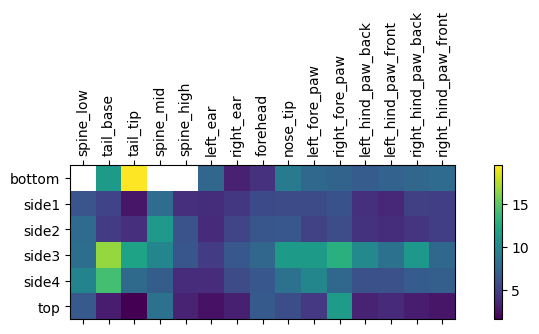

In [56]:
tr.run()